# Data Extraction

In [1]:
import obspy, tqdm, utils, os, random
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

## Creating waveform dataset

### 1. Extract pick information from quakeML files into `df_pick`

Takes 6.5 min to run.

In [2]:
data_dir = Path(utils.DATA_DIR)

paths = {
    "earthquakes": data_dir / "earthquakes2025.qkml",
    "explosions": data_dir / "explosions2025.qkml",
    "probable_explosions": data_dir / "probable_explosions2025.qkml",
}

catalogs = {}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    catalogs[name] = obspy.read_events(str(path))
    print(f"{name}: {len(catalogs[name])} events loaded from {path.name}")

# Dataframe of all earthquake, explosion and probable_explosion picks               
df_picks = utils.extract_picks(catalogs)
df_picks.to_csv(utils.FILENAME_PICKS, index=False) # Export to csv for possible debugging

print(f"\nTotal number of picks: {len(df_picks)}\n")
print(df_picks["Event type"].value_counts().to_frame(name="Number of picks"))
df_picks.head()

earthquakes: 328 events loaded from earthquakes2025.qkml
explosions: 599 events loaded from explosions2025.qkml
probable_explosions: 1455 events loaded from probable_explosions2025.qkml

Total number of picks: 54134

                     Number of picks
probable_explosions            32720
explosions                     14281
earthquakes                     7133


,Event id,SEED string,Pick type,Event type,Pick time
0,smi:fi.isuh/event/1490639,UP.LANU..BHZ,P,earthquakes,2025-01-01T09:22:01.256470Z
1,smi:fi.isuh/event/1490639,UP.LANU..BHZ,S,earthquakes,2025-01-01T09:22:07.069410Z
2,smi:fi.isuh/event/1490639,HE.HEF..BHZ,P,earthquakes,2025-01-01T09:22:02.651570Z
3,smi:fi.isuh/event/1490639,HE.HEF..BHZ,S,earthquakes,2025-01-01T09:22:09.394590Z
4,smi:fi.isuh/event/1490639,FN.KLF..BHZ,P,earthquakes,2025-01-01T09:22:07.766970Z


### 2. Identify windows to query waveforms from ISUH FDSNWS

Note about events:
* A seismic event can be detected by $\geq1$ station
* A station has zero or more P picks , and zero or more S-picks
* Therefore, a waveform indow will be uniquely identified by its event-station tuple (`Event id`, `SEED string short`)

Window definition:
* Each window should contain one P pick and one S pick, similar to the STEAD dataset used in benchmarking EQCCT. 
* The STEAD dataset uses 60s windows.
* But if P and S arrival times are too far from each other, each pick will be put in its own separate window to be queried. So there are windows that have one S pick only, or one P pick only

In [43]:
# Select picks for specified event types (i.e. earthquakes, explosions)
df_picks = df_picks[df_picks["Event type"].isin(utils.LIST_EVENT_TYPES)]

# Remove channel ID from the SEED string, so that the shortened SEED string can identify stations
df_picks["SEED string short"] = df_picks["SEED string"].str.rsplit(".", n=2).str[0] 

# Report how many P and S picks per event
utils.print_pick_summary(df_picks)

df_windows = df_picks.copy()

# Time of the earliest pick (usually P) for an event-station
df_windows["Event start"] = df_windows.groupby(["Event id", df_windows["SEED string short"]])["Pick time"].transform("min")

# Time of the latest pick (usually S) for an event-station
df_windows["Event end"] = df_windows.groupby(["Event id", df_windows["SEED string short"]])["Pick time"].transform("max")

# Ensure that query window starts 5s before the first pick (usually P)
df_windows["Win start"] = df_windows["Event start"] - utils.PRE_EVENT_BUFFER

# Ensure that query window is WIN_SIZE seconds long
df_windows["Win end"] = df_windows["Win start"] + utils.WIN_SIZE

# Report the number of far pairs i.e. event–station windows where the S arrival falls outside window
utils.print_far_pair_summary(df_windows)

# Proceed to put far pick into its own separate window
mask_far_pairs = df_windows["Win end"] - utils.POST_EVENT_BUFFER < df_windows["Event end"]
df_windows.loc[mask_far_pairs, "Win start"] = df_windows.loc[mask_far_pairs, "Pick time"] - utils.PRE_EVENT_BUFFER
df_windows.loc[mask_far_pairs, "Win end"] = df_windows.loc[mask_far_pairs, "Win start"] + utils.WIN_SIZE
df_windows.loc[mask_far_pairs, "Event id"] = df_windows.loc[mask_far_pairs, "Event id"] + df_windows.loc[mask_far_pairs, "Pick type"] # Each window will be identified by event-station fields later, but we need to distinguish between windows of far picks since they have their own separate windows, so we add suffix for differentiation

# Tag windows that contain picks from other events.
# We do not query these windows but keep them to accurately identify noise windows
def window_contains_other_event(row):
    others = df_windows[(df_windows["Event id"] != row["Event id"]) & \
                        (df_windows["SEED string short"] == row["SEED string short"])] 
    return ((others["Pick time"] >= row["Win start"]) & (others["Pick time"] <= row["Win end"])).any()

df_windows["Has overlap"] = df_windows.apply(window_contains_other_event, axis=1)

# Report the number of windows that contain picks from other events.
utils.print_overlap_summary(df_windows)

df_windows.to_csv(utils.FILENAME_WINDOWS, index=False)  # Save windows to CSV to run on eqcct in another virtual environment lol

----------- PICK SUMMARY -----------
  (num P picks, num S picks)  Number of event-stations
0                     (1, 1)                      8712
1                     (0, 1)                      2896
2                     (1, 0)                      1056
3                     (1, 2)                         6
4                     (0, 2)                         4
5                     (2, 1)                         4
Total number of event-stations: 12678

----------- FAR PAIR SUMMARY -----------
Max duration between P and S arrivals: 86.70201s
The window size of 60s is too short to contain some P, S pairs:
  * Number of event-stations with far pairs: 40
  * Number of picks affected: 81

----------- OVERLAP SUMMARY -----------
Number of windows containing picks from other events: 178,



### 3. Download event waveforms and generate labels

Wavforms are downloaded in .mseed format. 

Labels are stored in a CSV file, with the same columns as EQCCT's prediction output csv file. 


EQCCTPro's `create_dataset.py` utility is used by the function `download_window()` to download the waveforms. However, `create_dataset.py` does not have a callable function, so we invoke it using command line. Note that the `create_dataset.py` file is just copied from eqcct's repository.

The 2025 quakeML files contain picks for:
* Earthquake: 01.01.2025 to 31.12.2025
* Explosions: 01.01.2025 to ___28.02.2025___ (Shorter time range!)

Runtime stats on Cubbli Linux:
 * Earthquakes: 
    * ~21min to download windows from 01.01.2025 to 15.02.2025.
    * ~156min to download all windows from 01.01.2025 to 31.12.2025
 * Explosions
    * ~330min to dowload all windows from 01.01.2025 to 28.02.2025

In [ ]:
# Get all windows generated from catalog
df_windows = pd.read_csv(utils.FILENAME_WINDOWS)
df_windows = df_windows[~df_windows["Has overlap"]] # Ignore windows that contain picks from other events
df_windows["Win start"] = df_windows["Win start"].apply(obspy.UTCDateTime)
df_windows["Win end"] = df_windows["Win end"].apply(obspy.UTCDateTime)
df_windows["Pick time"] = df_windows["Pick time"].apply(obspy.UTCDateTime)
df_windows = df_windows.sort_values(["Pick time"]) # Sort pick time from earliest to latest

# Each window is uniquely identified by event id and station id (SEED string short)
df_win_groups = df_windows.groupby(["Event id", "SEED string short"])

# Define accumulators
df_y_eq = pd.DataFrame(columns=utils.COLUMNS_Y) # Dataframe to accummulate earthquake labels
df_y_ex = pd.DataFrame(columns=utils.COLUMNS_Y) # Dataframe to accummulate explosion labels
no_resp_seeds = [] # Accumulate SEED strings which returned an empty query on the FDSNWS

map_output = {"earthquakes": (utils.WAVEFORM_EQ_DIR, df_y_eq),
              "explosions": (utils.WAVEFORM_EX_DIR, df_y_ex)}

# Generate labels for each window. Each window has either both P and S times, or only one of them
for i, ((event_id, seed_string_s), df_group) in enumerate(df_win_groups):

    print(f"Download {i+1}/{len(df_win_groups)}   ", end="")

    win_start = df_group["Win start"].iloc[0]
    win_end = df_group["Win end"].iloc[0]
    seed_string = df_group["SEED string"].iloc[0]
    event_type = df_group["Event type"].iloc[0]

    network_code, station_code = seed_string_s.split(".")[:2]

    dir, df_y = map_output[event_type]
    status = utils.download_window(network_code, station_code, win_start, win_end, dir=dir)

    #  If the waveform can be downloaded, save the label
    if status:
        # If the event-station has multiple P (S) picks, choose the arrival time of the first P (S) pick
        p_time = df_group.loc[df_group["Pick type"].str.startswith("P"), "Pick time"].min() # np.nan if pick is absent
        s_time = df_group.loc[df_group["Pick type"].str.startswith("S"), "Pick time"].min() # np.nan if pick is absent
        
        seed_string = seed_string.replace("..", ".00.") # Fill in missing fields in SEED string with 00 to match eqcct's prediction output format
        
        file_name = seed_string + " | " + str(win_start) + " - " + str(win_end)
        row_df = pd.DataFrame([[file_name, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 
                                p_time, np.nan, s_time, np.nan]], columns=utils.COLUMNS_Y)
        df_y.loc[len(df_y)] = row_df.iloc[0] # append to the df this way because pd.concat is not helpful here

    # If download failed, record seed string for our inspection
    else:
        no_resp_seeds.append(seed_string_s)

df_y_eq.to_csv(utils.FILENAME_Y_EQ, index=False)
df_y_ex.to_csv(utils.FILENAME_Y_EX, index=False)
print(f"No data available for {len(no_resp_seeds)} windows. The SEED strings are:\n{no_resp_seeds}")

### 4. Download noise waveforms
Create the noise dataset and its labels. 

Runtime statistics:
* Earthquake noise (sampled from non-earthquake window time space): ~200min to download 4327 waveforms
* Earthquake and explosions noise (sampled from non-earthquake and non-explosion window time space): download 10147 waveforms

In [ ]:
df_windows = pd.read_csv(utils.FILENAME_WINDOWS)

# Get the range of dates to sample the noise waveforms fromm
df_windows["Pick time"] = df_windows["Pick time"].apply(utils.to_utc_or_none).dropna()

# The time range of known explosion events from the qkml files is smaller than that of earthquakes
win_sample_start = df_windows[df_windows["Event type"]=="explosions"]["Pick time"].min()
win_sample_end = df_windows[df_windows["Event type"]=="explosions"]["Pick time"].max()

# Get stations that were active during that event time range
station_list = utils.query_stations(win_sample_start, win_sample_end)

# Accummulate labels for noise windows
df_noise_labels = pd.DataFrame(columns=utils.COLUMNS_Y)

# Clear the noise waveform directory
os.system(f'rm -rf ./{utils.WAVEFORM_NOISE_DIR}/*')

# Download the noise window and store locally, equal to the number of labels
# for i in range(len(df_windows)):
for i in range(10):
    print(f"Download {i}/{len(df_windows)}   ", end="")
    # If no waveform available, requery until one is available 
    while True:
        cand_station = station_list[random.randrange(0, len(station_list)-1)] # Network.Station format (i.e'HE.SUF')

        # Generate a window which does not overlap with any event window
        win_start, win_end = utils.generate_noise_win(win_sample_start, win_sample_end, cand_station, df_windows)

        network_code, station_code = cand_station.split(".")

        status = utils.download_window(network_code, station_code, 
                                        win_start, win_end, 
                                        dir=utils.WAVEFORM_NOISE_DIR)
        
        if status: # If download successful, record the waveform in the noise label file
            file_name = f"{cand_station}.00.00 | {str(win_start)} - {str(win_end)}"
            row_df = pd.DataFrame([[file_name, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 
                            np.nan, np.nan, np.nan, np.nan]], columns=utils.COLUMNS_Y)
            df_noise_labels = pd.concat([df_noise_labels, row_df])
            break

df_noise_labels.to_csv(utils.FILENAME_Y_NOISE, index=False)

# Plot Dataset

### Plot earthquake event waveforms from local dataset

Load earthquake event waveforms from the local dataset and plot it against the true P and S arrival times from the labels file.

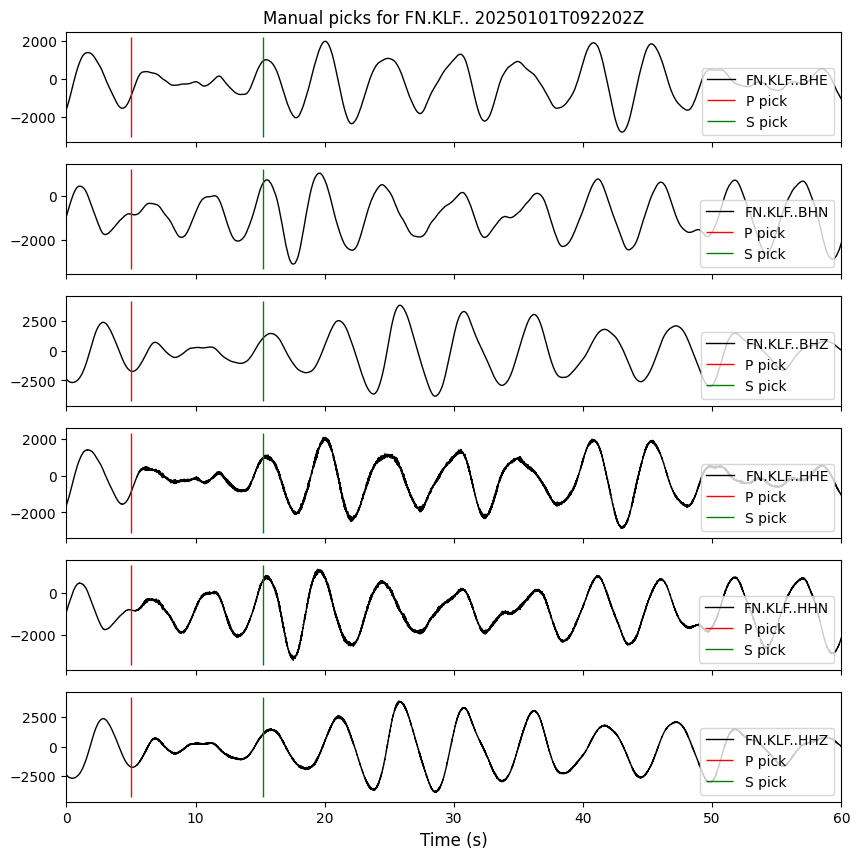

In [ ]:
max_rows = 1 # Maximum number of labels to read and plot

# Read the true P and S arrival times from labels.csv  
df_event_labels = pd.read_csv(utils.FILENAME_Y_EQ, nrows=max_rows)

# Iterate through each label, loading waveforms and plotting the true P and S arrival times on them
for row in df_event_labels.itertuples():

    network_code, station_code, win_start, win_end = utils.parse_label_filename(row.file_name)
    p_time = utils.to_utc_or_none(row.p_arrival_time)
    s_time = utils.to_utc_or_none(row.s_arrival_time)
    
    # Load the corresponding waveform from the locally-stored dataset
    st = utils.load_stream(win_start, win_end, network_code, station_code, dir=utils.WAVEFORM_EQ_DIR)
    if st:
        # If the waveform exists in the dataset, plot it with its true P and S arrival times
        utils.plot_traces(st,
                        ptime=p_time,
                        stime=s_time,
                        title=f"Manual picks for {network_code}.{station_code}.. {win_start}",
                        figname=Path(utils.VIS_DIR) / f"{network_code} {station_code} {win_start}.png", # If set, save plot as file
                        showf=True) # If set, show plot 

### Plot earthquake noise waveforms from local dataset

Load earthquake noise waveforms from the local dataset

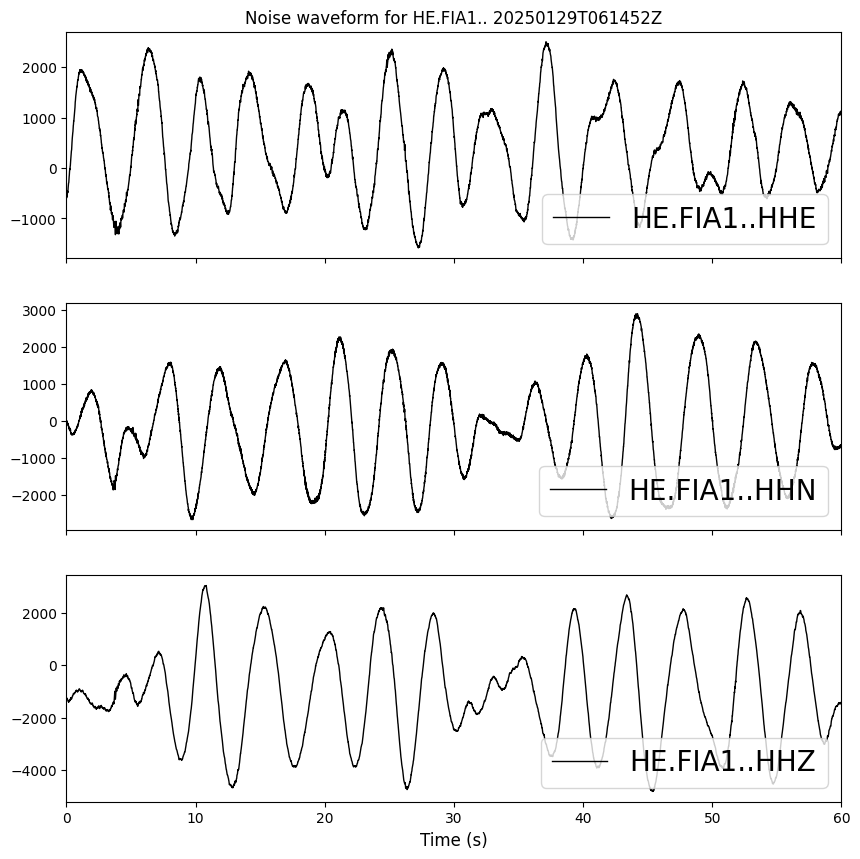

In [5]:
max_rows = 1 # Maximum number of labels to read and plot

# Read the true P and S arrival times from labels.csv  
df_noise_labels = pd.read_csv(utils.FILENAME_Y_NOISE, nrows=max_rows)

# Iterate through each label, loading waveforms and plotting the true P and S arrival times on them
for row in df_noise_labels.itertuples():

    network_code, station_code, win_start, win_end = utils.parse_label_filename(row.file_name)
    
    # Load the corresponding waveform from the locally-stored dataset
    st = utils.load_stream(win_start, win_end, network_code, station_code, dir=utils.WAVEFORM_NOISE_DIR)
    p_time = utils.to_utc_or_none(row.p_arrival_time) # Placed here to demonstrate there are no picks
    s_time = utils.to_utc_or_none(row.s_arrival_time) # Placed here to demonstrate there are no picks
    
    if st:
        # If the waveform exists in the dataset, plot it with its true P and S arrival times
        utils.plot_traces(st,
                        ptime=p_time,
                        stime=s_time,
                        title=f"Noise waveform for {network_code}.{station_code}.. {win_start}",
                        figname=Path(utils.VIS_DIR) / f"{network_code} {station_code} {win_start}.png", # If set, save plot as file
                        showf=True) # If set, show plot 